# Normalization techniques:
- MinMax Scaler (give the range (0,1))
- Mean Normalization (centers the data to origin)
- MaxAbsScaling 
- Robust Scaling (hanles outliers)

In [27]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns = ['Class Label','Alcohol','Malic acid']
df.sample(5)

,Class Label,Alcohol,Malic acid
174,3,13.40,3.91
143,3,13.62,4.95
36,1,13.28,1.64
125,2,12.07,2.16
160,3,12.36,3.83


<Axes: xlabel='Alcohol', ylabel='Density'>

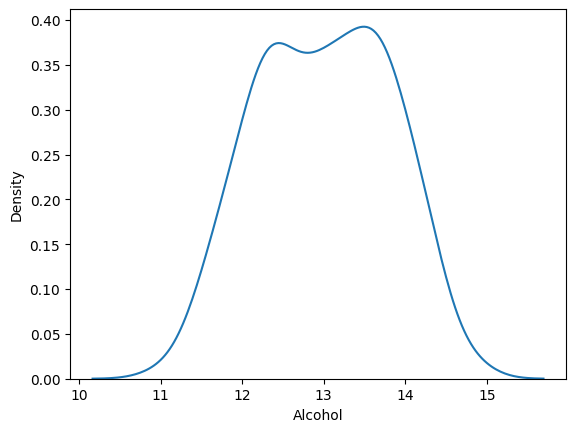

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

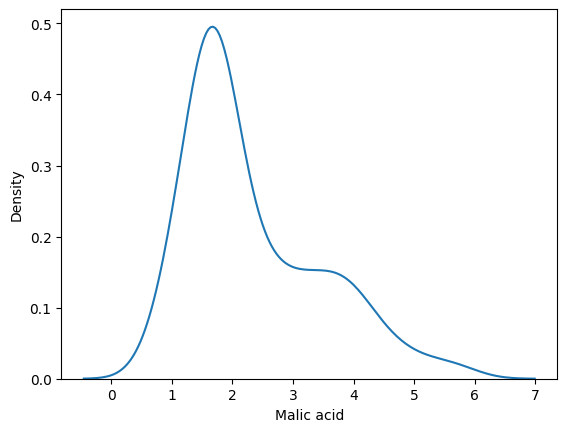

In [7]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

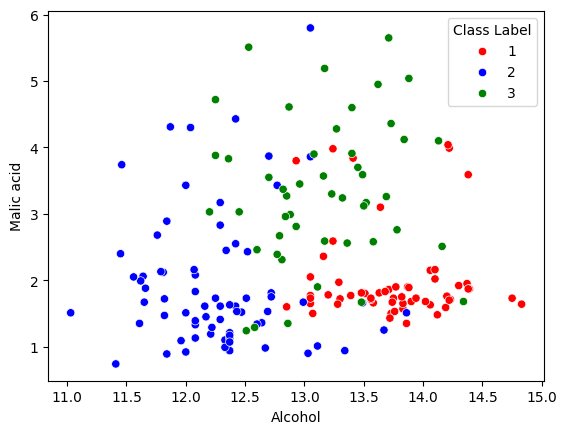

In [13]:
col_dict = {1:'red',2:'blue',3:'green'}
sns.scatterplot(data = df,x='Alcohol',y='Malic acid',hue='Class Label',palette=col_dict)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Class Label',axis=1),
                                                df['Class Label'],
                                                test_size = 0.3,
                                                 random_state=0)

x_train.shape,x_test.shape

((124, 2), (54, 2))

### MinMax Scaling 

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit only train data
scaler.fit(x_train)

# Transform both train and test data
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [23]:
# Sklearn transfroms the data into array , so array -> dataframe
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [24]:
round(x_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [26]:
round(x_train_scaled.describe(),1)
# Min = 0 & Max =1 (MinMax Scaler Property)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


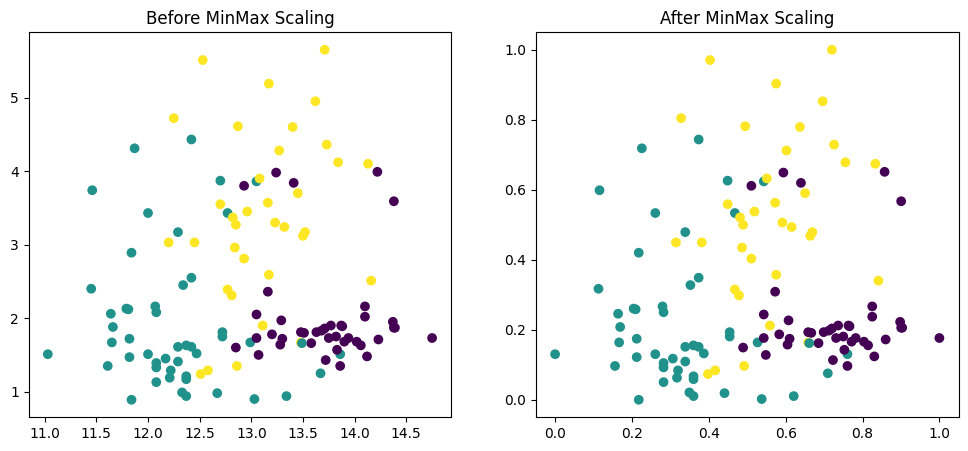

In [46]:
fig ,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train)
ax1.set_title('Before MinMax Scaling')
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'], c=y_train)
ax2.set_title('After MinMax Scaling')  #scales have changed

plt.show()

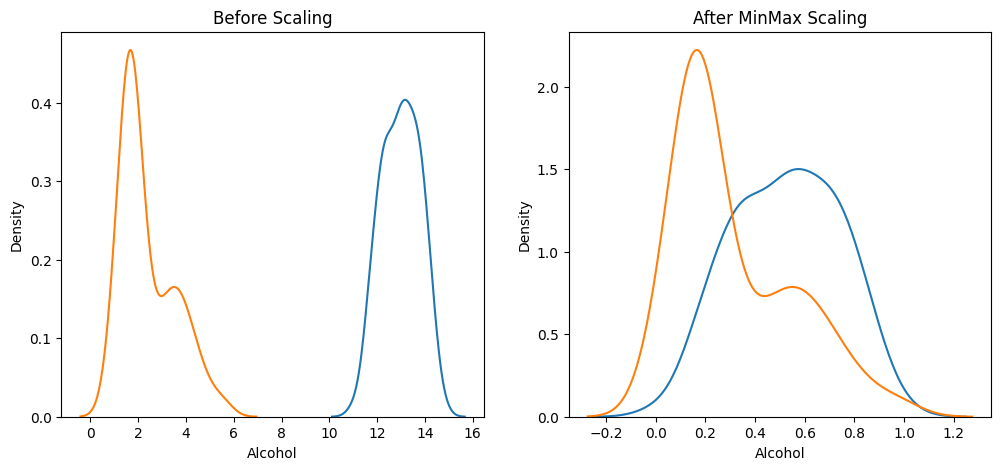

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After MinMax Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()